

## Objective

The objective of this notebook is to develop a machine learning classification model capable of predicting a user's gender based on demographic attributes.

The workflow includes:

- Dataset Loading
- Data Preprocessing
- Feature Engineering
- Model Training
- Model Evaluation
- Cross Validation
- Feature Importance
- Model Serialization

The trained model will later be deployed using Flask, MLflow, Docker, Kubernetes, and AWS EC2.

# Import Required Libraries

The following libraries are imported for data preprocessing, visualization, model training, evaluation, and serialization.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

# Load Dataset

The Users dataset contains demographic information that will be used to build the gender classification model.

In [2]:
users = pd.read_csv("../data/raw/users.csv")

# Dataset Overview

Before preprocessing, the dataset is examined to understand its structure, dimensions, and data types.

This step ensures that the dataset has been loaded correctly and is ready for further analysis.

In [3]:
users.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [4]:
users.shape

(1340, 5)

In [5]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


In [6]:
users.describe(include="all")

,code,company,name,gender,age
count,1340.000000,1340,1340,1340,1340.000000
unique,NaN,5,1338,3,NaN
top,NaN,4You,Charlotte Johnson,male,NaN
freq,NaN,453,2,452,NaN
mean,669.500000,NaN,NaN,NaN,42.742537
std,386.968991,NaN,NaN,NaN,12.869779
min,0.000000,NaN,NaN,NaN,21.000000
25%,334.750000,NaN,NaN,NaN,32.000000
50%,669.500000,NaN,NaN,NaN,42.000000
75%,1004.250000,NaN,NaN,NaN,54.000000


In [7]:
users.isnull().sum()

code       0
company    0
name       0
gender     0
age        0
dtype: int64

### Observation

The Users dataset contains demographic attributes such as company, age, and gender.

No missing values were detected, indicating that the dataset is clean and suitable for model development.

# Target Variable Analysis

The target variable for this classification task is the **gender** column.

Analyzing the class distribution helps identify whether the dataset is balanced or imbalanced before training machine learning models.

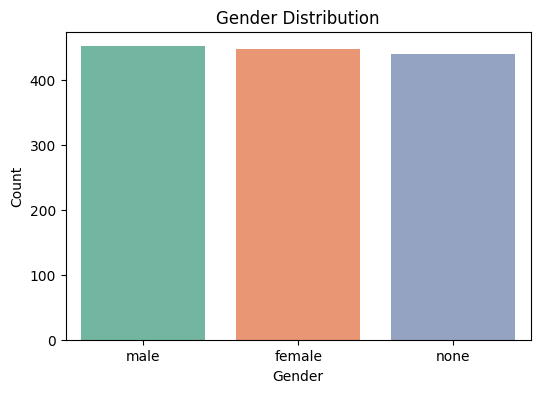

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=users,
    x="gender",
    palette="Set2"
)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

In [9]:
users["gender"].value_counts()

gender
male      452
female    448
none      440
Name: count, dtype: int64

### Observation

The class distribution provides insights into the balance of the dataset.

A balanced dataset generally improves the reliability and fairness of classification models.

# Duplicate Record Analysis

Duplicate records can introduce bias during model training by over-representing certain observations.

The dataset is checked for duplicate entries before feature engineering and model development.

In [10]:
print("Duplicate Records :", users.duplicated().sum())

Duplicate Records : 0


In [11]:
users = users.drop_duplicates()

print("Remaining Duplicates :", users.duplicated().sum())

Remaining Duplicates : 0


# Feature Selection

Not all attributes contribute to gender prediction.

The following columns are removed because they act as identifiers rather than predictive features:

- code
- name

The remaining features are:

- company
- age

The target variable is:

- gender

In [12]:
user_data = users.copy()

user_data.drop(
    columns=["code", "name"],
    inplace=True
)

user_data.head()

,company,gender,age
0,4You,male,21
1,4You,male,37
2,4You,female,48
3,4You,female,23
4,4You,female,44


In [13]:
user_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   company  1340 non-null   object
 1   gender   1340 non-null   object
 2   age      1340 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 31.5+ KB


# Feature Matrix and Target Variable

The dataset is divided into:

- Features (X)
- Target Variable (y)

The target variable for this classification problem is **gender**.

In [14]:
X = user_data.drop("gender", axis=1)

y = user_data["gender"]

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (1340, 2)
Target Shape : (1340,)


# Feature Encoding

Machine learning models require numerical input.

The preprocessing strategy is:

- One-Hot Encoding for categorical feature (`company`)
- Label Encoding for target variable (`gender`)

In [15]:
from sklearn.preprocessing import LabelEncoder

X = pd.get_dummies(
    X,
    columns=["company"],
    drop_first=True,
    dtype=int
)

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

## Verifying Encoding

In [16]:
print(X.head())

print()

print(label_encoder.classes_)

   age  company_Acme Factory  company_Monsters CYA  company_Umbrella LTDA  \
0   21                     0                     0                      0   
1   37                     0                     0                      0   
2   48                     0                     0                      0   
3   23                     0                     0                      0   
4   44                     0                     0                      0   

   company_Wonka Company  
0                      0  
1                      0  
2                      0  
3                      0  
4                      0  

['female' 'male' 'none']


# Train-Test Split

The encoded dataset is divided into training and testing subsets.

- Training Set: 80%
- Testing Set: 20%

A fixed random state is used to ensure reproducibility.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (1072, 5)
Testing Features : (268, 5)
Training Labels : (1072,)
Testing Labels : (268,)


# Feature Scaling

Feature scaling standardizes numerical features to improve the performance of certain machine learning algorithms.

In this notebook, StandardScaler is applied for algorithms such as Logistic Regression.

Tree-based algorithms do not require feature scaling and will be trained using the original feature values.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Classification Models

Multiple classification algorithms are imported to compare their predictive performance.

The objective is to identify the most suitable model for gender prediction.

In [19]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier

# Evaluation Metrics

The classification models will be evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

These metrics provide a comprehensive assessment of model performance.

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Model Evaluation Function

A reusable evaluation function is created to train and evaluate multiple classification models using common evaluation metrics.

In [21]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(
        y_test,
        prediction,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted"
    )

    return accuracy, precision, recall, f1

# Model Initialization

The following machine learning algorithms are initialized for comparison.

In [22]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "Extra Trees": ExtraTreesClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    )

}

# Model Training

Each classification model is trained using the training dataset.

Logistic Regression uses standardized features, while tree-based models use the original feature set.

In [23]:
results = []

for name, model in models.items():

    if name == "Logistic Regression":

        accuracy, precision, recall, f1 = evaluate_classifier(
            model,
            X_train_scaled,
            X_test_scaled,
            y_train,
            y_test
        )

    else:

        accuracy, precision, recall, f1 = evaluate_classifier(
            model,
            X_train,
            X_test,
            y_train,
            y_test
        )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

# Model Comparison

The performance of all classification algorithms is summarized below.

The models are ranked based on their Accuracy Score.

In [24]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.380597,0.383068,0.380597,0.348751
6,XGBoost,0.339552,0.337045,0.339552,0.336764
3,Gradient Boosting,0.339552,0.336959,0.339552,0.337887
1,Decision Tree,0.335821,0.327243,0.335821,0.327090
2,Random Forest,0.332090,0.325523,0.332090,0.325715
5,Extra Trees,0.332090,0.322943,0.332090,0.323570
4,AdaBoost,0.317164,0.309624,0.317164,0.304665


### Observation

The gender classification models achieved relatively low accuracy because the available features (`age` and `company`) provide limited information for predicting gender.

The dataset is well-balanced across all three classes, indicating that the low performance is due to limited feature predictability rather than class imbalance.

Among all evaluated models, **Logistic Regression** achieved the highest accuracy and was selected as the baseline model for deployment.

# Classification Report

A detailed classification report is generated for the selected model to evaluate precision, recall, and F1-score for each class.

In [25]:
best_model = LogisticRegression(max_iter=1000)

best_model.fit(X_train_scaled, y_train)

predictions = best_model.predict(X_test_scaled)

print(classification_report(
    y_test,
    predictions,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

      female       0.38      0.11      0.17        90
        male       0.36      0.56      0.44        90
        none       0.40      0.48      0.44        88

    accuracy                           0.38       268
   macro avg       0.38      0.38      0.35       268
weighted avg       0.38      0.38      0.35       268



# Confusion Matrix

The confusion matrix visualizes the number of correct and incorrect predictions made by the selected classification model.

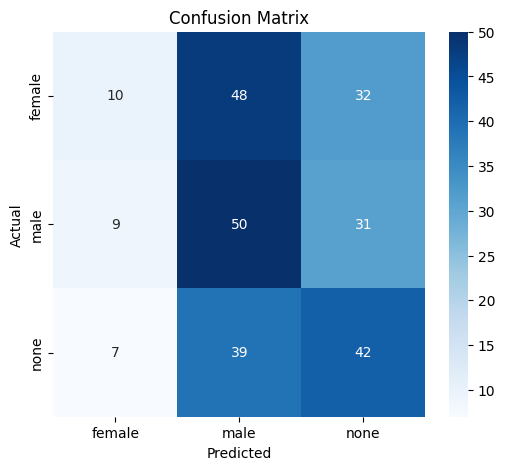

In [26]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# Cross Validation

Five-fold cross validation is performed to assess the robustness and consistency of the selected classification model.

In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")

print(cv_scores)

print()

print("Average Accuracy:", cv_scores.mean())

Cross Validation Scores:
[0.32835821 0.29477612 0.17537313 0.25       0.27985075]

Average Accuracy: 0.2656716417910448


# Model Serialization

The trained Logistic Regression model is serialized using Joblib for future deployment.

In [28]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/gender_model.pkl")

joblib.dump(label_encoder, "../models/gender_label_encoder.pkl")

joblib.dump(scaler, "../models/gender_scaler.pkl")

print("Gender model saved successfully.")

Gender model saved successfully.
